# Week 4 In-Class Work

This project is to perform EDA on cardio data sets.

In [40]:
# Import Necessary Packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as skl

In [41]:
# Ingest CSV Data from the Source
# Source: https://github.com/Welltory/hrv-covid19/tree/master/data
import json
import urllib.request
from pathlib import Path

REPO_DATA_API = "https://api.github.com/repos/Welltory/hrv-covid19/contents/data"
DATA_DIR = Path("data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

# List files in the repo's data folder and download each CSV (skip ones already saved)
with urllib.request.urlopen(REPO_DATA_API) as resp:
    repo_files = json.load(resp)

csv_files = [f for f in repo_files if f["name"].endswith(".csv")]
for f in csv_files:
    dest = DATA_DIR / f["name"]
    if dest.exists() and dest.stat().st_size == f["size"]:
        print(f"Already downloaded: {dest}")
        continue
    print(f"Downloading {f['name']} ({f['size'] / 1e6:.2f} MB)...")
    urllib.request.urlretrieve(f["download_url"], dest)

Already downloaded: data/blood_pressure.csv
Already downloaded: data/heart_rate.csv
Already downloaded: data/hrv_measurements.csv
Already downloaded: data/participants.csv
Already downloaded: data/scales_description.csv
Already downloaded: data/sleep.csv
Already downloaded: data/surveys.csv
Already downloaded: data/wearables.csv
Already downloaded: data/weather.csv


## Read the CSV Data and Parse the Data

In [42]:
# Read each CSV into its own DataFrame
blood_pressure_df = pd.read_csv(DATA_DIR / "blood_pressure.csv")
heart_rate_df = pd.read_csv(DATA_DIR / "heart_rate.csv")
hrv_measurements_df = pd.read_csv(DATA_DIR / "hrv_measurements.csv")
participants_df = pd.read_csv(DATA_DIR / "participants.csv")
scales_description_df = pd.read_csv(DATA_DIR / "scales_description.csv")
sleep_df = pd.read_csv(DATA_DIR / "sleep.csv")
surveys_df = pd.read_csv(DATA_DIR / "surveys.csv")
wearables_df = pd.read_csv(DATA_DIR / "wearables.csv")
weather_df = pd.read_csv(DATA_DIR / "weather.csv")

df_list = [
    blood_pressure_df,
    heart_rate_df,
    hrv_measurements_df,
    participants_df,
    scales_description_df,
    sleep_df,
    surveys_df,
    wearables_df,
    weather_df
]

# Confirm each DataFrame loaded
for name, df in {
    "blood_pressure": blood_pressure_df,
    "heart_rate": heart_rate_df,
    "hrv_measurements": hrv_measurements_df,
    "participants": participants_df,
    "scales_description": scales_description_df,
    "sleep": sleep_df,
    "surveys": surveys_df,
    "wearables": wearables_df,
    "weather": weather_df,
}.items():
    print(f"{name}: {df.shape}")

blood_pressure: (721, 8)
heart_rate: (523783, 4)
hrv_measurements: (3245, 22)
participants: (185, 8)
scales_description: (148, 4)
sleep: (425, 12)
surveys: (2259, 5)
wearables: (3098, 18)
weather: (1717, 7)


In [43]:
# View the Data Structure of each DataFrame
for df in df_list:
    print("\nData Structure")
    print('-' * 15)
    print(f"Dimensions: {df.shape}\n")
    print(f"Data Types:\n{df.dtypes}\n")
    print(f"Missing Values:\n{df.isnull().sum()}")

    '''
    print(df.head())
    print(df.info())
    print(df.describe())
    print('\n', '-' * 75, '\n')
    '''


Data Structure
---------------
Dimensions: (721, 8)

Data Types:
user_code                       str
measurement_datetime            str
diastolic                     int64
systolic                      int64
functional_changes_index    float64
circulatory_efficiency      float64
kerdo_vegetation_index      float64
robinson_index              float64
dtype: object

Missing Values:
user_code                     0
measurement_datetime          0
diastolic                     0
systolic                      0
functional_changes_index    422
circulatory_efficiency      422
kerdo_vegetation_index      438
robinson_index              422
dtype: int64

Data Structure
---------------
Dimensions: (523783, 4)

Data Types:
user_code       str
datetime        str
heart_rate    int64
is_resting    int64
dtype: object

Missing Values:
user_code     0
datetime      0
heart_rate    0
is_resting    0
dtype: int64

Data Structure
---------------
Dimensions: (3245, 22)

Data Types:
user_code            

In [44]:
# View the Statistical Summary of each DataFrame
for df in df_list:
    # Descriptive Statistics
    print("\nDescriptive Statistics")
    print("----------------------")
    numeric_columns = df.select_dtypes(include=[np.number]).columns
    print("Central Tendency Measures:")
    print(df[numeric_columns].describe().loc[['mean', '50%']])
    print("\nDispersion Measures:")
    print(df[numeric_columns].describe().loc[['std', 'min', 'max']])

    # Check for distribution normality (skewness and kurtosis)
    print("\nDistribution Measures:")
    print("------------------------")
    print(df[numeric_columns].skew())
    print(df[numeric_columns].kurt())


Descriptive Statistics
----------------------
Central Tendency Measures:
      diastolic    systolic  functional_changes_index  circulatory_efficiency  \
mean  81.228849  119.441054                  2.594013             2735.197057   
50%   82.000000  120.000000                  2.580000             2640.000000   

      kerdo_vegetation_index  robinson_index  
mean              -15.498233       84.663779  
50%               -17.000000       83.220000  

Dispersion Measures:
      diastolic    systolic  functional_changes_index  circulatory_efficiency  \
std    8.865761   10.522578                  0.291302               747.88257   
min   25.000000   63.000000                  1.680000              1300.00000   
max  101.000000  157.000000                  3.510000              7875.00000   

     kerdo_vegetation_index  robinson_index  
std               18.681233       14.399208  
min              -76.000000       49.500000  
max               45.000000      164.850000  

Distribut

### Data Context

The data appears to have a variety of metrics being measured.

We have multiple data sets that track the following:

1) Cardio Health
2) Sleep Analysis
3) Survey Results
4) Participant Facts
5) Wearable Measurements
6) Weather Patterns

We can observe that the data sets are messy: there are missing values, duplicate values, and outliers.

## Data Cleaning

For the sleep/blood-pressure comparison, the unit of analysis is one participant-day. Cleaning and merge choices:

1) Remove exact duplicate rows, but drop missing values only from fields required for this analysis. Optional sleep-stage and pulse fields are retained because removing every row with any null leaves almost no sleep data.
2) Convert the blood-pressure timestamp and sleep wake-up day to a common daily key. Both `user_code` and `day` are required so measurements from different participants are never paired.
3) Average multiple blood-pressure readings within a day. Use the median sleep duration within a day because the source contains repeated sleep records with shifted timestamps; the median avoids double-counting them.
4) Use an inner join because correlation analysis requires both sleep and blood-pressure values. Validate the join as one-to-one to guard against accidental row multiplication.

Sleep duration is converted from seconds to hours. Two analysis features are created: pulse pressure (`systolic - diastolic`) and absolute sleep deviation from an eight-hour reference. The sleep-deviation feature can reveal whether blood pressure is associated with sleep durations that are farther from the reference, rather than assuming only a linear effect of additional sleep. Outlier handling should be evaluated separately and justified before records are removed.

In [45]:
# Clean only the fields required for the sleep/blood-pressure comparison
blood_pressure_df_cleaned = blood_pressure_df.drop_duplicates().copy()
sleep_df_cleaned = sleep_df.drop_duplicates().copy()

blood_pressure_df_cleaned['measurement_datetime'] = pd.to_datetime(
    blood_pressure_df_cleaned['measurement_datetime'], errors='coerce'
)
blood_pressure_df_cleaned['day'] = (
    blood_pressure_df_cleaned['measurement_datetime'].dt.normalize()
)
sleep_df_cleaned['day'] = pd.to_datetime(
    sleep_df_cleaned['day'], errors='coerce'
).dt.normalize()

blood_pressure_df_cleaned = blood_pressure_df_cleaned.dropna(
    subset=['user_code', 'day', 'systolic', 'diastolic']
)
sleep_df_cleaned = sleep_df_cleaned.dropna(
    subset=['user_code', 'day', 'sleep_duration']
)

# Aggregate before merging so each participant-day occurs once in each table
blood_pressure_daily = (
    blood_pressure_df_cleaned
    .groupby(['user_code', 'day'], as_index=False)
    .agg(
        systolic=('systolic', 'mean'),
        diastolic=('diastolic', 'mean'),
        bp_readings=('systolic', 'size'),
    )
)
sleep_daily = (
    sleep_df_cleaned
    .groupby(['user_code', 'day'], as_index=False)
    .agg(
        sleep_duration_seconds=('sleep_duration', 'median'),
        sleep_records=('sleep_duration', 'size'),
    )
)
sleep_daily['sleep_duration_hours'] = sleep_daily['sleep_duration_seconds'] / 3600

# Keep participant-days observed in both sources and verify no row multiplication
merged_bps_df = blood_pressure_daily.merge(
    sleep_daily,
    on=['user_code', 'day'],
    how='inner',
    validate='one_to_one',
)
merged_bps_df['pulse_pressure'] = (
    merged_bps_df['systolic'] - merged_bps_df['diastolic']
)
merged_bps_df['sleep_deviation_from_8h'] = (
    merged_bps_df['sleep_duration_hours'] - 8
).abs()

print(f'Matched participant-days: {len(merged_bps_df)}')
print(merged_bps_df.head())

Matched participant-days: 44
    user_code        day  systolic  diastolic  bp_readings  \
0  0d297d2410 2020-01-13     127.0  82.000000            2   
1  6be5033971 2020-01-24     126.0  77.000000            1   
2  6be5033971 2020-05-15     112.0  75.666667            3   
3  6be5033971 2020-05-16     110.0  70.000000            2   
4  6be5033971 2020-05-18     119.0  80.000000            3   

   sleep_duration_seconds  sleep_records  sleep_duration_hours  \
0                 18900.0              1              5.250000   
1                 14100.0              1              3.916667   
2                 31500.0              1              8.750000   
3                 29400.0              1              8.166667   
4                 36600.0              1             10.166667   

   pulse_pressure  sleep_deviation_from_8h  
0       45.000000                 2.750000  
1       49.000000                 4.083333  
2       36.333333                 0.750000  
3       40.000000    

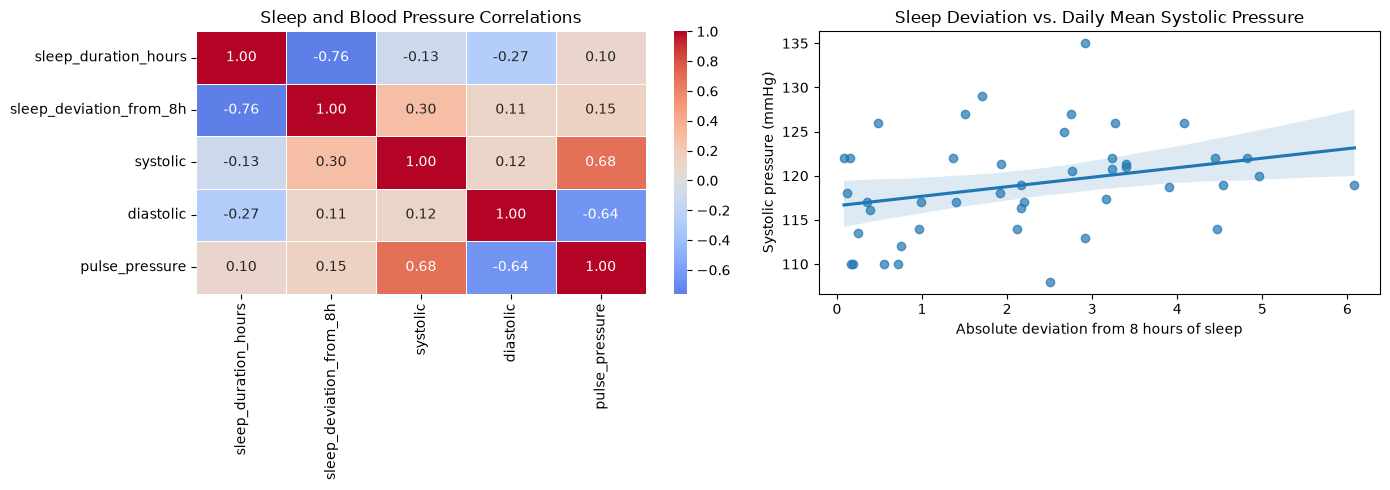

                         sleep_duration_hours  sleep_deviation_from_8h  \
sleep_duration_hours                     1.00                    -0.76   
sleep_deviation_from_8h                 -0.76                     1.00   
systolic                                -0.13                     0.30   
diastolic                               -0.27                     0.11   
pulse_pressure                           0.10                     0.15   

                         systolic  diastolic  pulse_pressure  
sleep_duration_hours        -0.13      -0.27            0.10  
sleep_deviation_from_8h      0.30       0.11            0.15  
systolic                     1.00       0.12            0.68  
diastolic                    0.12       1.00           -0.64  
pulse_pressure               0.68      -0.64            1.00  


In [46]:
# Compare sleep duration with the daily blood-pressure measures
analysis_columns = [
    'sleep_duration_hours', 'sleep_deviation_from_8h',
    'systolic', 'diastolic', 'pulse_pressure',
]
correlation_matrix = merged_bps_df[analysis_columns].corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(
    correlation_matrix, annot=True, cmap='coolwarm', center=0,
    fmt='.2f', linewidths=.5, ax=axes[0]
)
axes[0].set_title('Sleep and Blood Pressure Correlations')

sns.regplot(
    data=merged_bps_df, x='sleep_deviation_from_8h', y='systolic', ax=axes[1],
    scatter_kws={'alpha': 0.7}
)
axes[1].set(
    title='Sleep Deviation vs. Daily Mean Systolic Pressure',
    xlabel='Absolute deviation from 8 hours of sleep',
    ylabel='Systolic pressure (mmHg)',
)
plt.tight_layout()
plt.show()

print(correlation_matrix.round(2))

## Wrap-Up

### Scope, context, and sampling

This exploratory analysis profiled nine related health and context tables from the public Welltory `hrv-covid19` GitHub repository, then focused on the relationship between recorded sleep duration and blood pressure. The blood-pressure table contains 721 observations from 28 participants, while the sleep table contains 425 observations from 10 participants. Although five participants appear in both source tables, matching both participant and wake-up day produced 44 participant-days from only three participants between January 3 and June 17, 2020. This is a small, non-random observational sample with repeated measurements from the same people, so the results describe this sample only and should not be interpreted as causal or generalized to a wider population.

### Structure, preparation, and data quality

The initial profiling examined dimensions, data types, missingness, descriptive statistics, skewness, and kurtosis across all tables. For the focal analysis, the required blood-pressure fields (`user_code`, timestamp, systolic, and diastolic) and sleep fields (`user_code`, day, and sleep duration) were complete. In contrast, optional sleep-stage and pulse fields were missing in 398 to 418 of the 425 sleep rows. Dropping every row containing any null would therefore have reduced the sleep data to one row, so null removal was limited to fields necessary for this analysis.

No exact duplicate rows were found in either focal table, but both contained repeated participant-day keys. Blood-pressure readings were averaged within each participant-day. Sleep duration was summarized with the daily median because some same-day records had identical durations but shifted timestamps, suggesting duplicate or time-zone representations; using the median avoided double-counting them. Timestamps were parsed and normalized to a daily key, and sleep duration was transformed from seconds to hours. The tables were inner-joined on both `user_code` and `day`, and `validate='one_to_one'` enforced referential integrity and prevented many-to-many row multiplication.

Potential outliers were assessed through ranges, skewness, kurtosis, and the visualizations. The broader blood-pressure data included extreme values, while the matched sample ranged from 108 to 135 mmHg systolic, 70 to 94 mmHg diastolic, and 1.92 to 10.92 hours of sleep. No matched observations were automatically deleted: the sample is already small, the focal values are possible, and medically motivated exclusions would require verified collection context. Daily aggregation and the median sleep estimate reduce the influence of repeated or unusually timed records without imposing unsupported clinical cutoffs.

From a quality perspective, **profiling** exposed sparsity and non-normal variables; **completeness** was high for the focal fields but poor for optional sleep measures; **accuracy** cannot be independently confirmed because device calibration and user behavior were not audited; **consistency** was improved by standardizing dates, units, and daily granularity; **integrity** was protected with a composite merge key and one-to-one validation; and **lineage/provenance** is traceable to the public repository and the CSV download step in this notebook, although upstream collection and processing details remain limitations.

### Features, visual analysis, and findings

Two new features were created and documented. `pulse_pressure` is the difference between systolic and diastolic pressure. `sleep_deviation_from_8h` is the absolute distance between observed sleep and an eight-hour reference, allowing the analysis to test whether sleep farther from the reference is associated with blood pressure rather than assuming that every additional hour has the same linear effect. A correlation heatmap compared the transformed sleep and blood-pressure variables, and a regression scatterplot displayed sleep deviation against daily mean systolic pressure.

Across the 44 matched participant-days, mean sleep duration was 6.39 hours, mean systolic pressure was 119.00 mmHg, mean diastolic pressure was 83.04 mmHg, and mean pulse pressure was 35.96 mmHg. Sleep duration had weak negative correlations with systolic ($r=-0.13$) and diastolic pressure ($r=-0.27$). Deviation from eight hours had a modest positive correlation with systolic pressure ($r=0.30$), but only weak correlations with diastolic pressure ($r=0.11$) and pulse pressure ($r=0.15$). The visualization therefore suggests that participant-days farther from eight hours of sleep may coincide with somewhat higher systolic pressure in this sample, but the relationship is weak, highly uncertain, and potentially driven by participant-level differences. The strong correlations involving pulse pressure are partly mechanical because that feature is calculated directly from systolic and diastolic pressure.

Overall, the analysis satisfies the exploration objective by documenting context and sampling, profiling structure and descriptive statistics, addressing missing values and duplicate keys, using a justified outlier strategy, transforming and merging the data, engineering new features, visualizing relationships, and assessing the major dimensions of data quality. A stronger follow-up would use more participants, account for repeated observations with participant-level modeling, verify time zones and measurement protocols, and include additional sleep-quality measures once their missingness can be resolved.